In [1]:
import os
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import MinMaxScaler
import pickle

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

In [2]:
# Station metadata
STATIONS = {
    "2590100": {"name": "SENOSHITA",    "river": "CHIKUGO GAWA",  "area": 2315.0, "lat": 33.3161, "lon": 130.4972},
    "2590101": {"name": "ARASE",        "river": "CHIKUGO GAWA",  "area": 1443.0, "lat": 33.3433, "lon": 130.8350},
    "2590200": {"name": "HINODE-BASHI", "river": "ONGA GAWA",     "area":  695.0, "lat": 33.7500, "lon": 130.7300},
    "2590210": {"name": "MUTABE",       "river": "MATSUURA GAWA", "area":  275.0, "lat": 33.3600, "lon": 130.0100},
    "2590220": {"name": "TAMANA",       "river": "KIKUCHI GAWA",  "area":  906.0, "lat": 32.9400, "lon": 130.5900},
    "2590230": {"name": "ONOBUCHI",     "river": "SENDAI GAWA",   "area": 1348.0, "lat": 31.8600, "lon": 130.3400},
    "2590300": {"name": "YOKOISHI",     "river": "KUMA GAWA",     "area": 1856.0, "lat": 32.4600, "lon": 130.6600},
    "2590301": {"name": "HITOYOSHI",    "river": "KUMA GAWA",     "area": 1137.0, "lat": 32.2100, "lon": 130.7700},
    "2590400": {"name": "KASHIWADA",    "river": "OYODO GAWA",    "area": 2126.0, "lat": 31.9500, "lon": 131.4000},
    "2590401": {"name": "HIWATASHI",    "river": "OYODO GAWA",    "area":  860.6, "lat": 31.8600, "lon": 131.1000},
}

with open("data/processed/station_order.json") as f:
    STATION_ORDER = json.load(f)

N = len(STATION_ORDER)

A_norm = np.load("data/processed/adj_norm.npy")

wide = pd.read_csv("data/processed/daily_discharge.csv",
                   index_col="date", parse_dates=True)

print(f"Station order : {STATION_ORDER}")
print(f"Wide shape    : {wide.shape}")
print(f"Adjacency     : {A_norm.shape}")

Station order : ['2590100', '2590101', '2590200', '2590210', '2590220', '2590230', '2590300', '2590301', '2590400', '2590401']
Wide shape    : (9496, 10)
Adjacency     : (10, 10)


In [3]:
START = "1993-01-01"
END   = "2003-12-31"

wide = wide.loc[START:END, STATION_ORDER]

print(f"Modelling window : {START} → {END}")
print(f"Shape after clip : {wide.shape}")
print(f"\nMissing per station:")
for sid in STATION_ORDER:
    n = wide[sid].isna().sum()
    print(f"  {STATIONS[sid]['name']:15s}  {n} missing  ({n/len(wide)*100:.1f}%)")

Modelling window : 1993-01-01 → 2003-12-31
Shape after clip : (4017, 10)

Missing per station:
  SENOSHITA        0 missing  (0.0%)
  ARASE            0 missing  (0.0%)
  HINODE-BASHI     0 missing  (0.0%)
  MUTABE           0 missing  (0.0%)
  TAMANA           17 missing  (0.4%)
  ONOBUCHI         0 missing  (0.0%)
  YOKOISHI         0 missing  (0.0%)
  HITOYOSHI        0 missing  (0.0%)
  KASHIWADA        2 missing  (0.0%)
  HIWATASHI        2 missing  (0.0%)


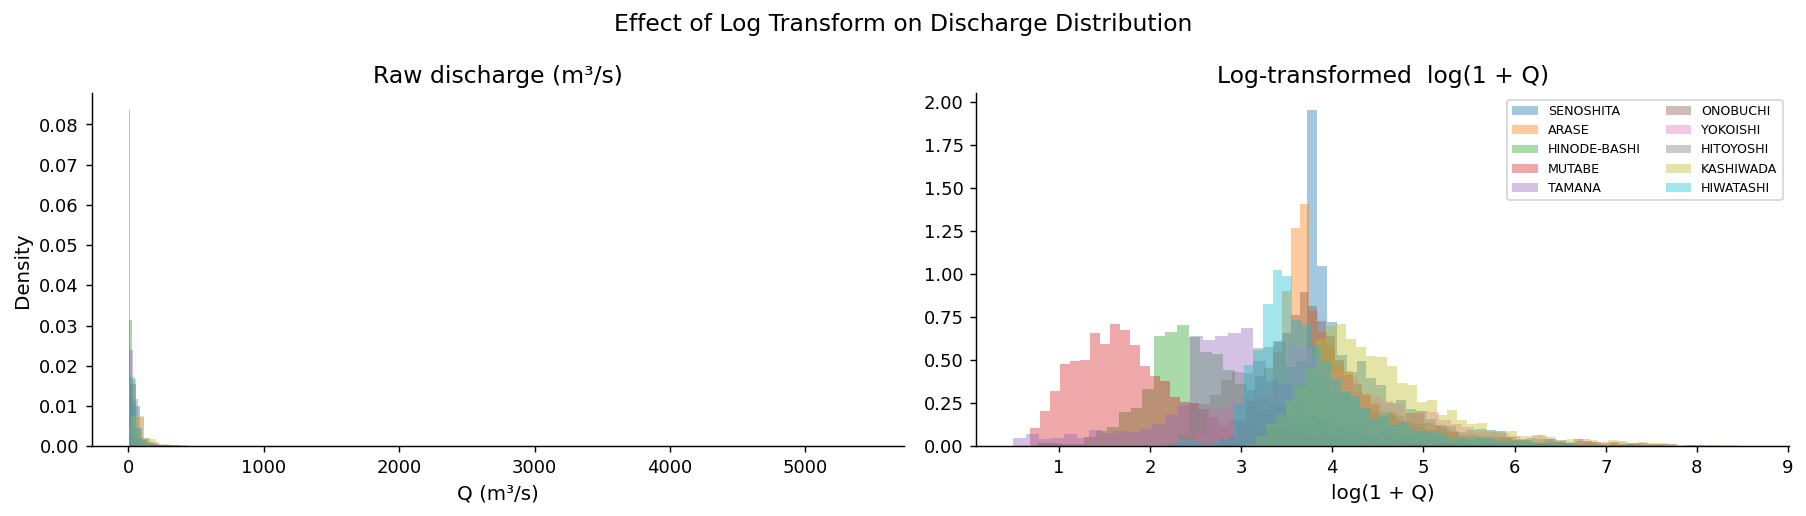

In [4]:
# Log-transform: log(1 + Q)

wide_log = np.log1p(wide)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Before
ax = axes[0]
for i, sid in enumerate(STATION_ORDER):
    s = wide[sid].dropna()
    ax.hist(s, bins=50, alpha=0.4, density=True,
            label=STATIONS[sid]["name"], color=plt.cm.tab10.colors[i])
ax.set_title("Raw discharge (m³/s)")
ax.set_xlabel("Q (m³/s)")
ax.set_ylabel("Density")

# After
ax = axes[1]
for i, sid in enumerate(STATION_ORDER):
    s = wide_log[sid].dropna()
    ax.hist(s, bins=50, alpha=0.4, density=True,
            label=STATIONS[sid]["name"], color=plt.cm.tab10.colors[i])
ax.set_title("Log-transformed  log(1 + Q)")
ax.set_xlabel("log(1 + Q)")
ax.legend(fontsize=7, ncol=2, loc="upper right")

plt.suptitle("Effect of Log Transform on Discharge Distribution", fontsize=13)
plt.tight_layout()
plt.show()

In [5]:
def build_features(wide_log, station_order, stations):
    """
    Build per-station feature DataFrame.

    Features (all computed on log-transformed discharge):
        discharge       : log(1 + Q) at time t  [target + input]
        lag_1d          : discharge at t-1
        lag_3d          : discharge at t-3
        lag_7d          : discharge at t-7
        lag_14d         : discharge at t-14
        roll_7d_mean    : 7-day rolling mean (shift 1 to avoid leakage)
        roll_7d_std     : 7-day rolling std
        sin_doy         : sin(2π * day_of_year / 365.25)
        cos_doy         : cos(2π * day_of_year / 365.25)
        area_norm       : log-normalised catchment area (static)
    """
    max_area = max(v["area"] for v in stations.values())
    feat_dict = {}

    for sid in station_order:
        s = wide_log[sid]
        df = pd.DataFrame(index=wide_log.index)

        df["discharge"]    = s
        df["lag_1d"]       = s.shift(1)
        df["lag_3d"]       = s.shift(3)
        df["lag_7d"]       = s.shift(7)
        df["lag_14d"]      = s.shift(14)
        df["roll_7d_mean"] = s.shift(1).rolling(7).mean()
        df["roll_7d_std"]  = s.shift(1).rolling(7).std()

        doy = df.index.day_of_year
        df["sin_doy"]  = np.sin(2 * np.pi * doy / 365.25)
        df["cos_doy"]  = np.cos(2 * np.pi * doy / 365.25)
        df["area_norm"] = np.log1p(stations[sid]["area"]) / np.log1p(max_area)

        feat_dict[sid] = df

    return feat_dict


feat_dict = build_features(wide_log, STATION_ORDER, STATIONS)

# Show feature names and sample for one station
sid_example = STATION_ORDER[0]
print(f"Features for {STATIONS[sid_example]['name']}:")
print(f"  Columns : {list(feat_dict[sid_example].columns)}")
print(f"  Shape   : {feat_dict[sid_example].shape}")
print()
print(feat_dict[sid_example].iloc[14:17])

Features for SENOSHITA:
  Columns : ['discharge', 'lag_1d', 'lag_3d', 'lag_7d', 'lag_14d', 'roll_7d_mean', 'roll_7d_std', 'sin_doy', 'cos_doy', 'area_norm']
  Shape   : (4017, 10)

            discharge    lag_1d    lag_3d    lag_7d   lag_14d  roll_7d_mean  \
date                                                                          
1993-01-15   3.995445  3.996180  3.857778  3.818591  3.766072      3.857900   
1993-01-16   3.839022  3.995445  3.763059  3.727619  3.753027      3.883165   
1993-01-17   4.003690  3.839022  3.996180  3.888140  3.731460      3.899079   

            roll_7d_std   sin_doy   cos_doy  area_norm  
date                                                    
1993-01-15     0.097272  0.255182  0.966893        1.0  
1993-01-16     0.107762  0.271777  0.962360        1.0  
1993-01-17     0.087233  0.288291  0.957543        1.0  


In [6]:
TRAIN_END = "2000-12-31"
VAL_END   = "2001-12-31"

def temporal_split(feat_dict, train_end, val_end):
    train, val, test = {}, {}, {}
    for sid, df in feat_dict.items():
        train[sid] = df.loc[:train_end]
        val[sid]   = df.loc[train_end:val_end].iloc[1:]
        test[sid]  = df.loc[val_end:].iloc[1:]
    return train, val, test

train_dict, val_dict, test_dict = temporal_split(feat_dict, TRAIN_END, VAL_END)

example = STATION_ORDER[0]
print("Split sizes (rows per station):")
print(f"  Train : {len(train_dict[example])}  ({train_dict[example].index[0].date()} → {train_dict[example].index[-1].date()})")
print(f"  Val   : {len(val_dict[example])}  ({val_dict[example].index[0].date()} → {val_dict[example].index[-1].date()})")
print(f"  Test  : {len(test_dict[example])}  ({test_dict[example].index[0].date()} → {test_dict[example].index[-1].date()})")

Split sizes (rows per station):
  Train : 2922  (1993-01-01 → 2000-12-31)
  Val   : 365  (2001-01-01 → 2001-12-31)
  Test  : 730  (2002-01-01 → 2003-12-31)


In [7]:
SCALE_COLS = ["discharge", "lag_1d", "lag_3d", "lag_7d",
              "lag_14d", "roll_7d_mean", "roll_7d_std"]

scalers = {}

for sid in STATION_ORDER:
    scaler = MinMaxScaler()
    train_vals = train_dict[sid][SCALE_COLS].dropna()
    scaler.fit(train_vals)
    scalers[sid] = scaler

print("Scalers fitted on training data only.")
print(f"Scaling columns : {SCALE_COLS}")
print()
print("Per-station data ranges (train, before scaling):")
for sid in STATION_ORDER:
    col = "discharge"
    mn  = train_dict[sid][col].min()
    mx  = train_dict[sid][col].max()
    print(f"  {STATIONS[sid]['name']:15s}  log(Q) range: [{mn:.2f}, {mx:.2f}]")


def apply_scaler(split_dict, scalers, scale_cols):
    """Apply fitted scalers to a split. Non-scaled columns are passed through."""
    result = {}
    for sid, df in split_dict.items():
        df_s = df.copy()
        mask = df_s[scale_cols].notna().all(axis=1)
        df_s.loc[mask, scale_cols] = scalers[sid].transform(df_s.loc[mask, scale_cols])
        result[sid] = df_s
    return result


train_scaled = apply_scaler(train_dict, scalers, SCALE_COLS)
val_scaled   = apply_scaler(val_dict,   scalers, SCALE_COLS)
test_scaled  = apply_scaler(test_dict,  scalers, SCALE_COLS)

print("\nScaling applied to train / val / test.")

Scalers fitted on training data only.
Scaling columns : ['discharge', 'lag_1d', 'lag_3d', 'lag_7d', 'lag_14d', 'roll_7d_mean', 'roll_7d_std']

Per-station data ranges (train, before scaling):
  SENOSHITA        log(Q) range: [2.73, 8.20]
  ARASE            log(Q) range: [2.77, 7.63]
  HINODE-BASHI     log(Q) range: [0.77, 7.13]
  MUTABE           log(Q) range: [0.69, 6.14]
  TAMANA           log(Q) range: [0.50, 7.43]
  ONOBUCHI         log(Q) range: [2.77, 7.63]
  YOKOISHI         log(Q) range: [2.25, 8.60]
  HITOYOSHI        log(Q) range: [2.19, 8.09]
  KASHIWADA        log(Q) range: [2.94, 8.45]
  HIWATASHI        log(Q) range: [2.28, 7.62]

Scaling applied to train / val / test.


In [8]:
def make_windows(split_scaled, station_order, input_len=14, horizon=7):
    """
    Build sliding-window tensors.

    Returns
    -------
    X : np.ndarray  (n_samples, input_len, N, n_features)
    y : np.ndarray  (n_samples, horizon, N)
        Target is the scaled 'discharge' column only.
    dates : list of forecast start dates (length n_samples)
    """
    # Align to common date index
    common_idx = split_scaled[station_order[0]].index
    for sid in station_order[1:]:
        common_idx = common_idx.intersection(split_scaled[sid].index)

    frames = [split_scaled[sid].loc[common_idx] for sid in station_order]
    feat_cols = frames[0].columns.tolist()
    target_col = "discharge"
    target_idx = feat_cols.index(target_col)

    # (T, N, F) arrays
    X_raw = np.stack([f[feat_cols].values for f in frames], axis=1).astype(np.float32)
    y_raw = np.stack([f[target_col].values for f in frames], axis=1).astype(np.float32)

    T = X_raw.shape[0]
    X_list, y_list, date_list = [], [], []

    for i in range(T - input_len - horizon + 1):
        x_win = X_raw[i : i + input_len]                        # (input_len, N, F)
        y_win = y_raw[i + input_len : i + input_len + horizon]  # (horizon, N)

        # Drop window if any NaN
        if np.isnan(x_win).any() or np.isnan(y_win).any():
            continue

        X_list.append(x_win)
        y_list.append(y_win)
        date_list.append(common_idx[i + input_len])

    X = np.stack(X_list)   # (samples, input_len, N, F)
    y = np.stack(y_list)   # (samples, horizon, N)
    return X, y, date_list, feat_cols


INPUT_LEN = 14
HORIZON   = 7

X_tr, y_tr, dates_tr, feat_cols = make_windows(train_scaled, STATION_ORDER, INPUT_LEN, HORIZON)
X_va, y_va, dates_va, _         = make_windows(val_scaled,   STATION_ORDER, INPUT_LEN, HORIZON)
X_te, y_te, dates_te, _         = make_windows(test_scaled,  STATION_ORDER, INPUT_LEN, HORIZON)

print(f"Feature columns : {feat_cols}")
print(f"n_features      : {len(feat_cols)}")
print()
print(f"X_train : {X_tr.shape}   y_train : {y_tr.shape}")
print(f"X_val   : {X_va.shape}   y_val   : {y_va.shape}")
print(f"X_test  : {X_te.shape}   y_test  : {y_te.shape}")

Feature columns : ['discharge', 'lag_1d', 'lag_3d', 'lag_7d', 'lag_14d', 'roll_7d_mean', 'roll_7d_std', 'sin_doy', 'cos_doy', 'area_norm']
n_features      : 10

X_train : (2773, 14, 10, 10)   y_train : (2773, 7, 10)
X_val   : (316, 14, 10, 10)   y_val   : (316, 7, 10)
X_test  : (674, 14, 10, 10)   y_test  : (674, 7, 10)


=== Window 100 ===
Forecast start date : 1993-05-09
X shape  : (14, 10, 10)  (input_len=14, N=10, F=10)
y shape  : (7, 10)  (horizon=7, N=10)


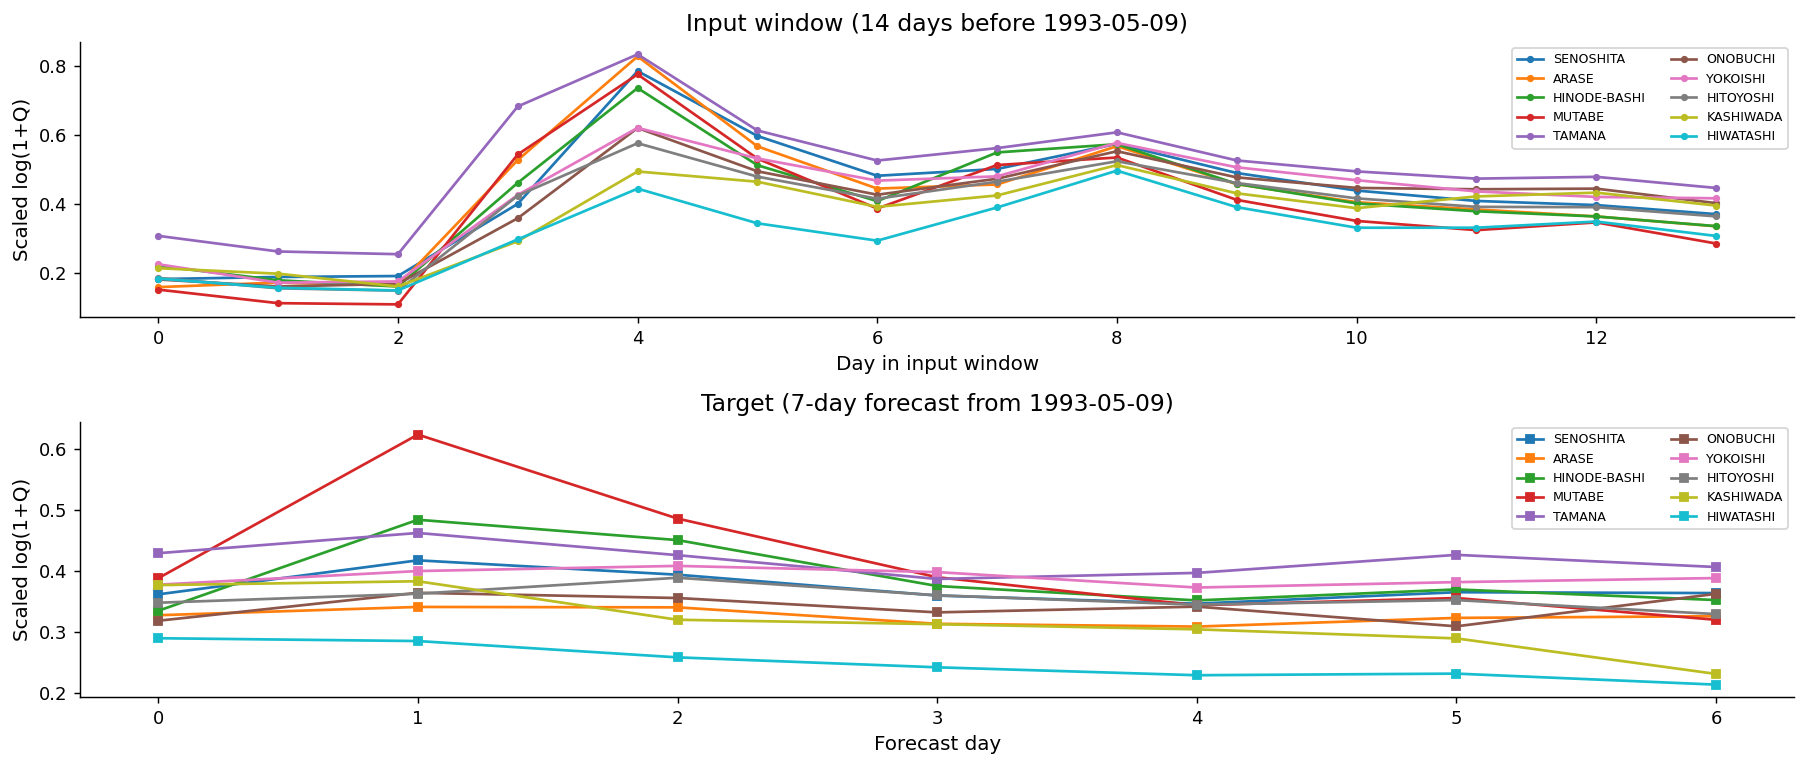

In [9]:
sample_idx = 100
print(f"=== Window {sample_idx} ===")
print(f"Forecast start date : {dates_tr[sample_idx].date()}")
print(f"X shape  : {X_tr[sample_idx].shape}  (input_len={INPUT_LEN}, N={N}, F={len(feat_cols)})")
print(f"y shape  : {y_tr[sample_idx].shape}  (horizon={HORIZON}, N={N})")

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)

# Input discharge across all stations (scaled)
ax = axes[0]
for i, sid in enumerate(STATION_ORDER):
    ax.plot(range(INPUT_LEN), X_tr[sample_idx, :, i, 0],
            marker="o", markersize=3, lw=1.5,
            color=plt.cm.tab10.colors[i],
            label=STATIONS[sid]["name"])
ax.set_title(f"Input window (14 days before {dates_tr[sample_idx].date()})")
ax.set_xlabel("Day in input window")
ax.set_ylabel("Scaled log(1+Q)")
ax.legend(fontsize=7, ncol=2)

# Target discharge across all stations (scaled)
ax = axes[1]
for i, sid in enumerate(STATION_ORDER):
    ax.plot(range(HORIZON), y_tr[sample_idx, :, i],
            marker="s", markersize=4, lw=1.5,
            color=plt.cm.tab10.colors[i],
            label=STATIONS[sid]["name"])
ax.set_title(f"Target (7-day forecast from {dates_tr[sample_idx].date()})")
ax.set_xlabel("Forecast day")
ax.set_ylabel("Scaled log(1+Q)")
ax.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

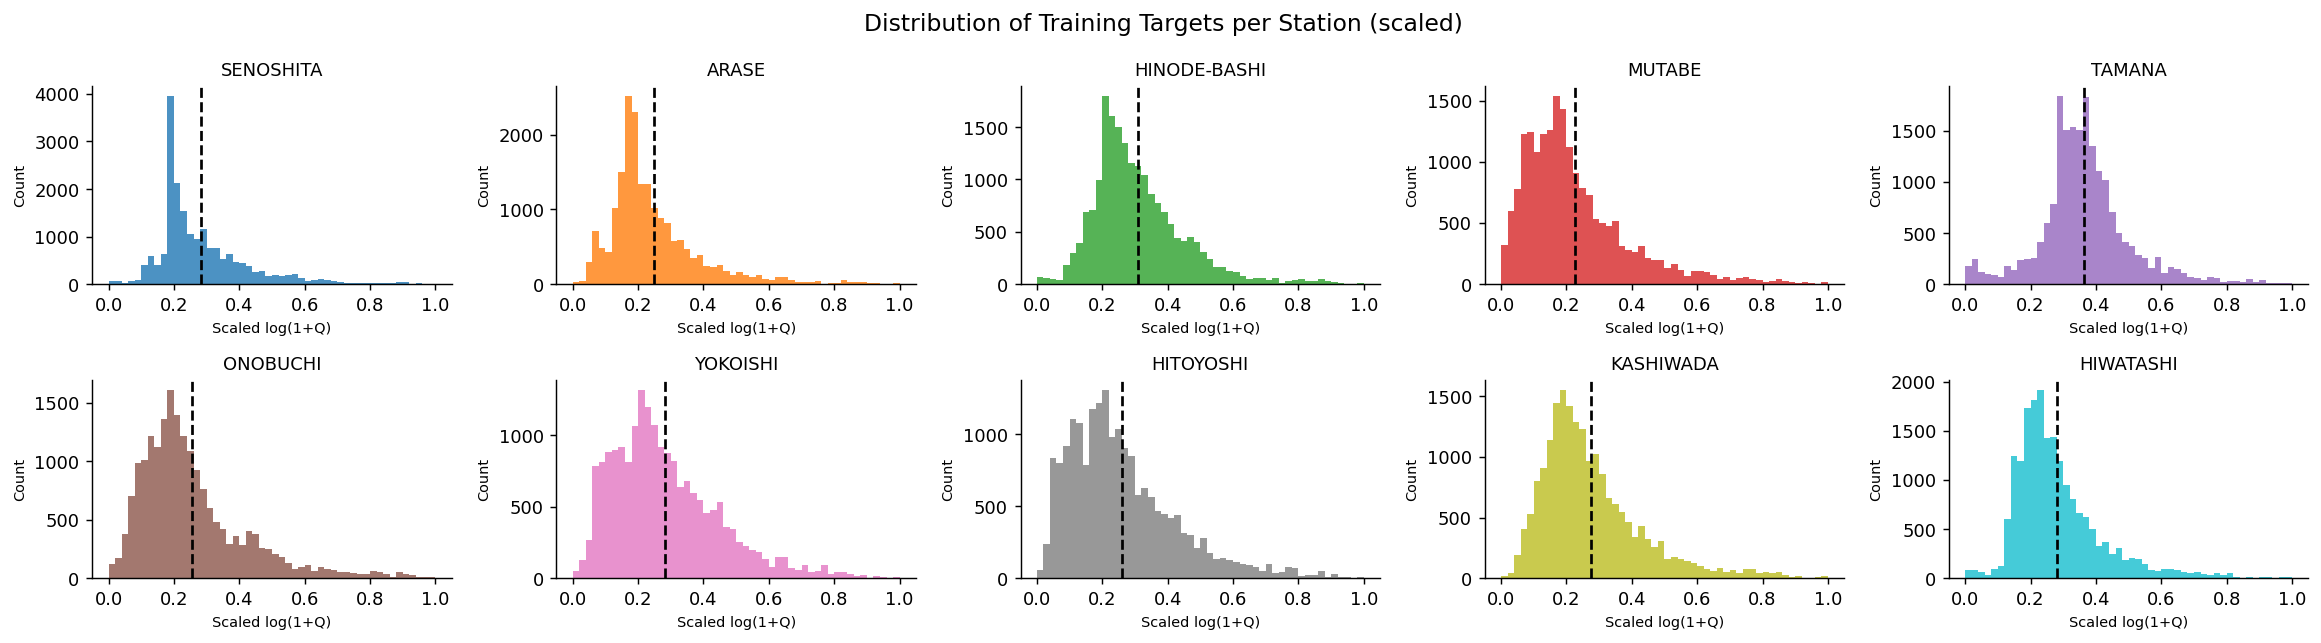

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(18, 5))
axes = axes.flatten()

for i, sid in enumerate(STATION_ORDER):
    ax = axes[i]
    # y values for this station across all training windows, all horizons
    vals = y_tr[:, :, i].flatten()
    ax.hist(vals, bins=50, color=plt.cm.tab10.colors[i], alpha=0.8, edgecolor="none")
    ax.set_title(STATIONS[sid]["name"], fontsize=10)
    ax.set_xlabel("Scaled log(1+Q)", fontsize=8)
    ax.set_ylabel("Count", fontsize=8)
    ax.axvline(vals.mean(), color="black", lw=1.5, linestyle="--")

plt.suptitle("Distribution of Training Targets per Station (scaled)", fontsize=13)
plt.tight_layout()
plt.show()

In [11]:
os.makedirs("data/processed", exist_ok=True)

# Arrays
np.save("data/processed/X_train.npy", X_tr)
np.save("data/processed/y_train.npy", y_tr)
np.save("data/processed/X_val.npy",   X_va)
np.save("data/processed/y_val.npy",   y_va)
np.save("data/processed/X_test.npy",  X_te)
np.save("data/processed/y_test.npy",  y_te)

with open("data/processed/scalers.pkl", "wb") as f:
    pickle.dump(scalers, f)

config = {
    "station_order": STATION_ORDER,
    "feat_cols":     feat_cols,
    "scale_cols":    SCALE_COLS,
    "input_len":     INPUT_LEN,
    "horizon":       HORIZON,
    "train_end":     TRAIN_END,
    "val_end":       VAL_END,
    "log_transform": True,
}
with open("data/processed/config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Saved:")
for fname in ["X_train","y_train","X_val","y_val","X_test","y_test"]:
    arr = np.load(f"data/processed/{fname}.npy")
    print(f"  {fname}.npy  {arr.shape}  dtype={arr.dtype}")
print("  scalers.pkl")
print("  config.json")

Saved:
  X_train.npy  (2773, 14, 10, 10)  dtype=float32
  y_train.npy  (2773, 7, 10)  dtype=float32
  X_val.npy  (316, 14, 10, 10)  dtype=float32
  y_val.npy  (316, 7, 10)  dtype=float32
  X_test.npy  (674, 14, 10, 10)  dtype=float32
  y_test.npy  (674, 7, 10)  dtype=float32
  scalers.pkl
  config.json
